---
## **Calculate and Examine the Protein Abundance Distributions for the Datasets**
Now that you have obtain a list of peptides that have been confidently matched to proteins of interest we need to process further to obtain estimates of the protein level abundances. \

## (III - 0) Imports and setup
Import some useful python packages for analyzing and plotting dataframes. 
Define the file path of the dataset you want and a label for the output files that are generated. 

In [3]:
import os, sys
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


## Define your root path as python notebooks require absolute paths to locate files
ROOT = os.path.abspath("../../")
print(f'Root path: {ROOT}')

## Define the path to the dataset
DATA = "data/Soybean_SAGE_results/final_results.csv" ## Soybean dataset
DATA = os.path.join(ROOT, DATA)
print(f'Using dataset: {DATA}')

## Check that the dataset file exists
if not os.path.isfile(DATA):
    print(f'Error: {DATA} not found.')
    raise FileNotFoundError
else:
    print(f'FILE EXISTS: {DATA}')

## Choose a label to differentiate any output files that are generated
dataLABEL = "Soybean" 
print(f'Using label: {dataLABEL}')


Root path: /home/ians/git_repos/CURE2025_Comparative_massSpec
Using dataset: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/Soybean_SAGE_results/final_results.csv
FILE EXISTS: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/Soybean_SAGE_results/final_results.csv
Using label: Soybean


## (III - 1) Filter the peptide tables
*Explanation*: Filters out low-confidence identifications. Only keeps peptides with q_value ≤ 0.05, controlling peptide-level false discovery. 
    
*Why*: Filtering by q-value ensures you are only using peptide measurements with statistical support propagating too many false positives would pollute protein-level inference.  
  
*Note*: The threshold (0.05) is conventional; students can try stricter (0.01) or looser as an exercise to see how discovery changes.  


In [4]:
## Load the data into a Pandas DataFrame and print the top 10 rows of the dataframe
df = pd.read_csv(DATA)
print(f'Loaded: {DATA}')
print(df.head())

## Filter the DataFrame based on q-value
df = df[df['q_value'] <= 0.05]  # Filter by q-value threshold
df = df[df['protein_q'] <= 0.05]  # Filter by q-value threshold
df = df[df['coverage_frac'] >= 0.20]  # Filter by coverage fraction threshold
print(f'Number of confidently mapped peptides in {dataLABEL} samples: {len(df)}')

Loaded: /home/ians/git_repos/CURE2025_Comparative_massSpec/data/Soybean_SAGE_results/final_results.csv
                           peptide  charge  \
0                          LEEVFNK       2   
1                          LEEVFNK       2   
2  ILKPDLIAPGVNILAGWTGAVGPTGLTVDTR       3   
3               SM[+15.9949]AQIALR       2   
4               SM[+15.9949]AQIALR       2   

                                            proteins   q_value     score  \
0      tr|C6T1K3|C6T1K3_SOYBN;tr|Q9FQF3|Q9FQF3_SOYBN  0.401699  0.950182   
1      tr|C6T1K3|C6T1K3_SOYBN;tr|Q9FQF3|Q9FQF3_SOYBN  0.401699  0.950182   
2                             tr|I1MXJ1|I1MXJ1_SOYBN  0.596639  0.210072   
3  tr|A0A0R0IFL4|A0A0R0IFL4_SOYBN;tr|I1MQN4|I1MQN...  0.007627  0.689876   
4  tr|A0A0R0IFL4|A0A0R0IFL4_SOYBN;tr|I1MQN4|I1MQN...  0.007627  0.689876   

   spectral_angle  Soybean_LPBiomaker_HP2.mzML  Soybean_LPBiomaker_LP2.mzML  \
0        0.984391                 2.340627e+07                 2.009559e+07   
1    

## (III - 2) Select and clean relevant columns for analysis
*Explanation:*

* Constructs a subset of columns: retaining `peptide`, the original `proteins` annotation, `q_value`, and all other columns except technical metadata (`charge`, `score`, `spectral_angle`) which are not needed for quantification.
* The `proteins` field is in UniProt format like `sp|P12345|PROT_NAME;tr|P12345|PROT_NAME;...`.
* For each peptide make a row copy for every protein it could possibly map to.
* Drops any peptides that failed to parse into a valid UniProt accession.
  
*Why:*
Reduces clutter and focuses downstream computation on actual intensity data and needed identifiers.  

*Teaching note:* Students can be asked what happens if peptides map to multiple proteins (this script doesn’t resolve shared peptides explicitly—it aggregates all evidence under each protein) and discuss how “razor” or parsimony approaches differ.

In [5]:
## Select and clean Human columns
import re
columns_of_interest = ['peptide', 'proteins', 'q_value'] + [col for col in df.columns if col not in ['peptide', 'proteins', 'q_value', 'charge', 'score', 'spectral_angle']]
clean_expanded_df = df[columns_of_interest]


## drop the columns we dont need
clean_expanded_df.drop(columns=['proteins'], inplace=True)

## Drop peptides without a recognized protein mapping
clean_expanded_df.dropna(subset=['uniprot'], inplace=True)
clean_expanded_df = clean_expanded_df.reset_index(drop=True)

## Rename the columns 
rename_mapping = {'Soybean_LPBiomaker_HP1.mzML': 'CONTROL_1',
                  'Soybean_LPBiomaker_HP2.mzML': 'CONTROL_2',
                  'Soybean_LPBiomaker_HP3.mzML': 'CONTROL_3',
                  'Soybean_LPBiomaker_LP1.mzML': 'TREATMENT_1',
                  'Soybean_LPBiomaker_LP2.mzML': 'TREATMENT_2',
                  'Soybean_LPBiomaker_LP3.mzML': 'TREATMENT_3'}
clean_expanded_df = clean_expanded_df.rename(columns=rename_mapping)


## Display the first few rows of the cleaned and expanded DataFrame
print(f'First few rows of the cleaned and expanded DataFrame:')
print(clean_expanded_df)

First few rows of the cleaned and expanded DataFrame:
                  peptide   q_value     CONTROL_2   TREATMENT_2     CONTROL_3  \
0      SM[+15.9949]AQIALR  0.007627  3.107053e+06  3.208076e+06  3.092634e+06   
1            ELISNASDALDK  0.009128  4.158766e+07  3.473105e+07  5.914646e+07   
2            ELISNASDALDK  0.009128  4.158766e+07  3.473105e+07  5.914646e+07   
3            ELISNASDALDK  0.009128  4.158766e+07  3.473105e+07  5.914646e+07   
4            ELISNASDALDK  0.009128  4.158766e+07  3.473105e+07  5.914646e+07   
...                   ...       ...           ...           ...           ...   
24693    TPLRPGGGVIFGPKPR  0.003552  5.464645e+07  7.464126e+06  5.378868e+07   
24694   VKDELILDGNDIELVSR  0.030124  5.193758e+07  1.454989e+06  1.421574e+07   
24695   VKDELILDGNDIELVSR  0.030124  5.193758e+07  1.454989e+06  1.421574e+07   
24696   VKDELILDGNDIELVSR  0.030124  5.193758e+07  1.454989e+06  1.421574e+07   
24697   VKDELILDGNDIELVSR  0.030124  5.193758e+07  1.45

/tmp/ipykernel_263272/1000468291.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_expanded_df.drop(columns=['proteins'], inplace=True)
/tmp/ipykernel_263272/1000468291.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_expanded_df.dropna(subset=['uniprot'], inplace=True)


## (III - 3) Estimate Protein Abundances
*Explanation:*

* Groups all peptides assigned to each UniProt accession and collapses their intensities per sample by taking the **median** across peptides.

*Why median?*
Median is robust to outliers (e.g., aberrant peptide measurements) and is a simple estimate of protein abundance from multiple peptide surrogates.

*Note:* Alternatives include mean, weighted mean (by peptide quality), or more sophisticated models (like MaxLFQ’s ratio-based inference). Students can compare results of median vs mean as an exploration.
https://www.nature.com/articles/nmeth.3901.pdf

In [6]:
import directlfq.lfq_manager as lfq_manager

example_input_file_diann = f"/tmp/example_input_file_diann.aq_reformat.tsv"
print(clean_expanded_df)
directlfq_df = clean_expanded_df.copy()
directlfq_df.drop(columns=['q_value'], inplace=True)
directlfq_df.rename(columns={'uniprot': 'protein', 'peptide': 'ion'}, inplace=True)
directlfq_df = directlfq_df[['protein', 'ion'] + list(rename_mapping.values())]
print(directlfq_df)
directlfq_df.to_csv(example_input_file_diann, sep="\t", index=False)


lfq_manager.run_lfq(example_input_file_diann)
protein_sample_abundance = pd.read_csv(f"/tmp/example_input_file_diann.aq_reformat.tsv.protein_intensities.tsv", sep="\t")
# set the index to the protein column
protein_sample_abundance.set_index("protein", inplace=True)
print(protein_sample_abundance)

/home/ians/miniconda3/envs/mass_spec_proteomics/lib/python3.9/site-packages/directlfq/utils.py:19: UserWarning: Dependency 'dask' not installed. If you want to use its functionality, install directlfq with the 'dask' extra. Falling back to non-dask based processing.
  warnings.warn("Dependency 'dask' not installed. If you want to use its functionality, install directlfq with the 'dask' extra. Falling back to non-dask based processing.")
2025-09-03 08:30:49,304 - directlfq.lfq_manager - INFO - Starting directLFQ analysis.
2025-09-03 08:30:49,389 - directlfq.lfq_manager - INFO - Performing sample normalization.


                  peptide   q_value     CONTROL_2   TREATMENT_2     CONTROL_3  \
0      SM[+15.9949]AQIALR  0.007627  3.107053e+06  3.208076e+06  3.092634e+06   
1            ELISNASDALDK  0.009128  4.158766e+07  3.473105e+07  5.914646e+07   
2            ELISNASDALDK  0.009128  4.158766e+07  3.473105e+07  5.914646e+07   
3            ELISNASDALDK  0.009128  4.158766e+07  3.473105e+07  5.914646e+07   
4            ELISNASDALDK  0.009128  4.158766e+07  3.473105e+07  5.914646e+07   
...                   ...       ...           ...           ...           ...   
24693    TPLRPGGGVIFGPKPR  0.003552  5.464645e+07  7.464126e+06  5.378868e+07   
24694   VKDELILDGNDIELVSR  0.030124  5.193758e+07  1.454989e+06  1.421574e+07   
24695   VKDELILDGNDIELVSR  0.030124  5.193758e+07  1.454989e+06  1.421574e+07   
24696   VKDELILDGNDIELVSR  0.030124  5.193758e+07  1.454989e+06  1.421574e+07   
24697   VKDELILDGNDIELVSR  0.030124  5.193758e+07  1.454989e+06  1.421574e+07   

        TREATMENT_1   TREAT

2025-09-03 08:30:50,765 - directlfq.lfq_manager - INFO - Estimating lfq intensities.
2025-09-03 08:30:50,767 - directlfq.protein_intensity_estimation - INFO - 2352 lfq-groups total
2025-09-03 08:30:51,622 - directlfq.protein_intensity_estimation - INFO - using 60 processes
2025-09-03 08:30:51,637 - directlfq.protein_intensity_estimation - INFO - lfq-object 0
2025-09-03 08:30:51,681 - directlfq.protein_intensity_estimation - INFO - lfq-object 100
2025-09-03 08:30:51,740 - directlfq.protein_intensity_estimation - INFO - lfq-object 200
2025-09-03 08:30:51,793 - directlfq.protein_intensity_estimation - INFO - lfq-object 300
2025-09-03 08:30:51,846 - directlfq.protein_intensity_estimation - INFO - lfq-object 400
2025-09-03 08:30:51,898 - directlfq.protein_intensity_estimation - INFO - lfq-object 500
2025-09-03 08:30:51,947 - directlfq.protein_intensity_estimation - INFO - lfq-object 600
2025-09-03 08:30:52,138 - directlfq.protein_intensity_estimation - INFO - lfq-object 700
2025-09-03 08:30

               CONTROL_1     CONTROL_2     CONTROL_3   TREATMENT_1  \
protein                                                              
A0A068JE73  3.498489e+06  2.237345e+06  1.233781e+06  9.386394e+06   
A0A068JEE3  1.487103e+06  8.652500e+05  5.872417e+05  1.280250e+04   
A0A068JF10  1.979185e+07  3.231246e+06  2.077922e+07  3.671482e+05   
A0A068JFC7  2.232802e+07  2.460509e+07  1.051477e+07  2.057551e+08   
A0A068JHD1  4.819507e+07  2.315286e+07  6.953536e+07  3.249901e+07   
...                  ...           ...           ...           ...   
Q9M507      1.169128e+08  1.405441e+08  1.272576e+08  1.077782e+08   
Q9M508      1.927016e+08  1.891344e+08  2.453926e+08  1.465575e+08   
Q9SWR5      9.402062e+06  1.630296e+07  8.799516e+06  1.430001e+07   
Q9XHC6      1.981794e+07  2.764257e+07  1.968972e+07  5.503142e+07   
Q9ZS21      4.537300e+06  4.591975e+06  5.389547e+06  3.159942e+06   

             TREATMENT_2   TREATMENT_3  
protein                                 
A0A068J

## (III - 4) Compute Sample Statistics and Make Box and Violin Plots of each Sample Separately
You should compute the following statistics for each sample:
1.	The estimated protein abundance mean
2.	The estimated protein abundance minimum and maximum
3.	The estimated protein abundance median
4.	The estimate protein abundance first and third quartiles
5.  The estimated protein abundance variance

In [7]:
import matplotlib.pyplot as plt
from scipy import stats
import textwrap

groups = {'CONTROL': ['CONTROL_1', 'CONTROL_2', 'CONTROL_3'],
          'TREATMENT': ['TREATMENT_1', 'TREATMENT_2', 'TREATMENT_3']}

## Function to compute the stats for each sample column 
def compute_stats(series, label):
    series = series.astype(float)
    print(f'series: {series}')
    print(sorted(series.values))
    print(np.where(series == 0))
    """Return a dict and dataframe of summary statistics for a 1D numeric pandas Series."""
    clean = series.dropna()
    if clean.empty:
        return {
            "count": 0,
            "mean": np.nan,
            "median": np.nan,
            "mode": [],
            "variance": np.nan,
            "quantiles": {}
        }
    # mode: use pandas.Series.mode() for compatibility
    mode_vals = clean.mode()
    if len(mode_vals) != 1:
        mode_vals = mode_vals[:1]
    print(f'mode_vals: {mode_vals}')

    results = {
        "count": int(clean.size),
        "mean": float(clean.mean()),
        "median": float(clean.median()),
        "mode": [float(m) for m in mode_vals] if not mode_vals.empty else [],
        "variance": float(clean.var(ddof=1)),  # sample variance
        "quantiles": {
            "0.0": float(clean.quantile(0.0)),
            "0.25": float(clean.quantile(0.25)),
            "0.5": float(clean.quantile(0.5)),
            "0.75": float(clean.quantile(0.75)),
            "1.0": float(clean.quantile(1.0)),
        }
    }
    results_df = {"count": int(clean.size),
                  "mean": float(clean.mean()),
                  "median": float(clean.median()),
                  "mode": [float(m) for m in mode_vals] if not mode_vals.empty else [],
                  "variance": float(clean.var(ddof=1)),  # sample variance,
                  "Q0.0": float(clean.quantile(0.0)),
                  "Q0.25": float(clean.quantile(0.25)),
                  "Q0.5": float(clean.quantile(0.5)),
                  "Q0.75": float(clean.quantile(0.75)),
                  "Q1.0": float(clean.quantile(1.0))}
    results_df = pd.DataFrame(results_df)
    results_df['file'] = label
    print(results_df)

    return results_df, results
    
## Compute per-sample stats
stats_dict = {}
stats_dfs = []
print(protein_sample_abundance)

# print the rows with 0s
# print(np.where(protein_sample_abundance == 0))

for k, v in groups.items():
    for c in v:
        print(f'\n{c}')
        
        stats_df, stats_dict[c] = compute_stats(protein_sample_abundance[c], c)
        stats_dfs.append(stats_df)
print(len(stats_dfs))
stats_df = pd.concat(stats_dfs)
print(stats_df)

               CONTROL_1     CONTROL_2     CONTROL_3   TREATMENT_1  \
protein                                                              
A0A068JE73  3.498489e+06  2.237345e+06  1.233781e+06  9.386394e+06   
A0A068JEE3  1.487103e+06  8.652500e+05  5.872417e+05  1.280250e+04   
A0A068JF10  1.979185e+07  3.231246e+06  2.077922e+07  3.671482e+05   
A0A068JFC7  2.232802e+07  2.460509e+07  1.051477e+07  2.057551e+08   
A0A068JHD1  4.819507e+07  2.315286e+07  6.953536e+07  3.249901e+07   
...                  ...           ...           ...           ...   
Q9M507      1.169128e+08  1.405441e+08  1.272576e+08  1.077782e+08   
Q9M508      1.927016e+08  1.891344e+08  2.453926e+08  1.465575e+08   
Q9SWR5      9.402062e+06  1.630296e+07  8.799516e+06  1.430001e+07   
Q9XHC6      1.981794e+07  2.764257e+07  1.968972e+07  5.503142e+07   
Q9ZS21      4.537300e+06  4.591975e+06  5.389547e+06  3.159942e+06   

             TREATMENT_2   TREATMENT_3  
protein                                 
A0A068J

### Make Box Plots and Violin plots of each Sample Separately

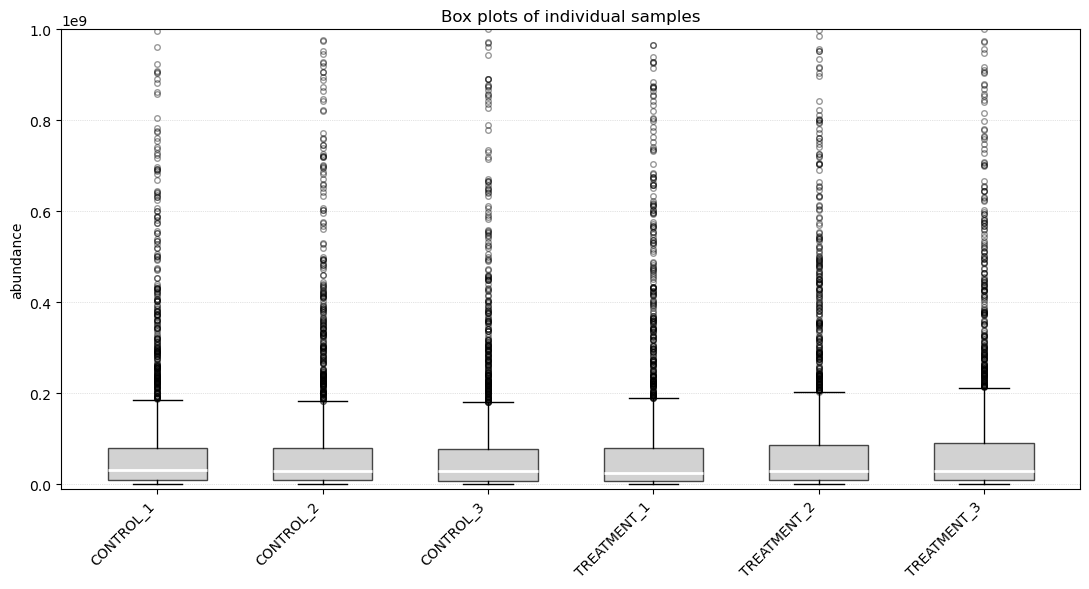

In [8]:
def plot_sample_boxplots(df, sample_cols, label_map, output_path=None, log_scale=False):
    """
    Box plots for individual samples with custom labels.

    Parameters
    ----------
    df : pd.DataFrame
        Protein abundance table (rows=proteins, cols=samples).
    sample_cols : List[str]
        Columns in df to plot.
    label_map : Dict[str,str]
        Mapping from sample column name to custom label for x-axis.
    output_path : str or None
        If given, saves figure to this path.
    log_scale : bool
        If True, plot log2(abundance + small pseudocount).
    """
    # Prepare data array for boxplot
    data = []
    labels = []
    for col in sample_cols:
        series = df[col]
        if log_scale:
            series = np.log2(series.replace(0, np.nan) + 1e-6)
        data.append(series.dropna().values)
        labels.append(label_map.get(col, col))

    fig, ax = plt.subplots(figsize=(1.5 * len(sample_cols) + 2, 6))
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, manage_ticks=False)

    # Light styling: gray boxes with white medians
    for box in bp['boxes']:
        box.set(facecolor='#c0c0c0', alpha=0.7, edgecolor='black')
    for whisker in bp['whiskers']:
        whisker.set(color='black', linewidth=1)
    for cap in bp['caps']:
        cap.set(color='black', linewidth=1)
    for median in bp['medians']:
        median.set(color='white', linewidth=2)
    for flier in bp['fliers']:
        flier.set(marker='o', alpha=0.4, markersize=4)

    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ylabel = "log2(abundance)" if log_scale else "abundance"
    ax.set_ylabel(ylabel)
    ax.set_title("Box plots of individual samples")
    ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.7)
    ax.set_ylim(-1e7, 1e9)
    fig.tight_layout()
    plt.show()
    # if output_path:
    #     fig.savefig(output_path, dpi=300)
    #     print(f"Saved violin plot to {output_path}")
    return fig, stats_dict

# Assume protein_abundance_df is your dataframe with uniprot index
sample_cols = [
    "CONTROL_1",
    "CONTROL_2",
    "CONTROL_3",
    "TREATMENT_1",
    "TREATMENT_2",
    "TREATMENT_3",
]
label_map = {
    "CONTROL_1": "CONTROL_1",
    "CONTROL_2": "CONTROL_2",
    "CONTROL_3": "CONTROL_3",
    "TREATMENT_1": "TREATMENT_1",
    "TREATMENT_2": "TREATMENT_2",
    "TREATMENT_3": "TREATMENT_3",
}

fig, stats = plot_sample_boxplots(protein_sample_abundance, sample_cols, label_map,
                                output_path="sample_boxplot.png", log_scale=False)

### Make Violin Plots and Violin plots of each Sample Separately

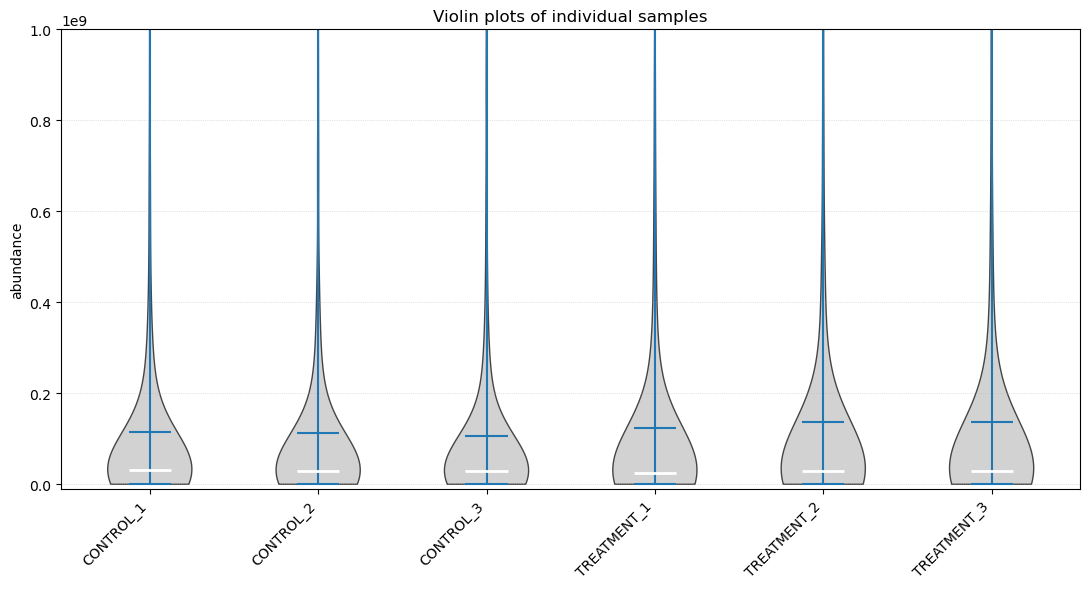

In [9]:
## Make violin plot
def plot_sample_violinplots(df, sample_cols, label_map, output_path=None, log_scale=False):
    """
    Violin plots for individual samples with custom labels.

    Parameters
    ----------
    df : pd.DataFrame
        Protein abundance table (rows=proteins, cols=samples).
    sample_cols : List[str]
        Columns in df to plot.
    label_map : Dict[str,str]
        Mapping from sample column name to custom label for x-axis.
    output_path : str or None
        If given, saves figure to this path.
    log_scale : bool
        If True, plot log2(abundance + small pseudocount).
    """
    # Prepare data array for violin plot
    data = []
    labels = []
    for col in sample_cols:
        series = df[col]
        if log_scale:
            series = np.log2(series.replace(0, np.nan) + 1e-6)
        data.append(series.dropna().values)
        labels.append(label_map.get(col, col))

    fig, ax = plt.subplots(figsize=(1.5 * len(sample_cols) + 2, 6))
    parts = ax.violinplot(data, showmeans=True, showmedians=True, showextrema=True, points=100000)

    # Light styling: gray violins with white medians
    for pc in parts['bodies']:
        pc.set_facecolor('#c0c0c0')
        pc.set_alpha(0.7)
        pc.set_edgecolor('black')
        pc.set_linewidth(1)
    if 'cmedians' in parts:
        parts['cmedians'].set_color('white')
        parts['cmedians'].set_linewidth(2)

    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ylabel = "log2(abundance)" if log_scale else "abundance"
    ax.set_ylabel(ylabel)
    ax.set_title("Violin plots of individual samples")
    ax.grid(axis='y', linestyle=':', linewidth=0.5, alpha=0.7)
    ax.set_ylim(-1e7, 1e9)
    fig.tight_layout()
    plt.show()
    # if output_path:
    #     fig.savefig(output_path, dpi=300)
    #     print(f"Saved violin plot to {output_path}")
    return fig

# Assume protein_abundance_df is your dataframe with uniprot index
sample_cols = [
    "CONTROL_1",
    "CONTROL_2",
    "CONTROL_3",
    "TREATMENT_1",
    "TREATMENT_2",
    "TREATMENT_3",
]
label_map = {
    "CONTROL_1": "CONTROL_1",
    "CONTROL_2": "CONTROL_2",
    "CONTROL_3": "CONTROL_3",
    "TREATMENT_1": "TREATMENT_1",
    "TREATMENT_2": "TREATMENT_2",
    "TREATMENT_3": "TREATMENT_3",
}

fig = plot_sample_violinplots(protein_sample_abundance, sample_cols, label_map,
                                output_path="sample_violinplot.png", log_scale=False)

## **Differential Protein Abundance Mass Spectrometry Data of Soybean Dataset**

## (IV - 0) Protein-level abundance statistics 
*Explanation*: For each protein calculate the mean, standard deviation, variance, and median across the technical replicates for the CONTROL and TREATMENT groups. Then calculate the log2(\<TREATMENT\>/\<CONTROL\>) for each protein to assing a magnitude to the observed change in abundance. 

*Why*: We are not only interested in the significance of the change in abundance observed but also the magnitude of the change.

In [10]:
## Calculate the protein level abundance statistics
groups = {'CONTROL': ['CONTROL_1', 'CONTROL_2', 'CONTROL_3'],
          'TREATMENT': ['TREATMENT_1', 'TREATMENT_2', 'TREATMENT_3']}
protein_abund_stats = {}
for group_name, cols in groups.items():
    print(group_name, cols)
    sub = protein_sample_abundance[cols]

    # Compute per-row stats; skip NaNs naturally
    protein_abund_stats[f"{group_name}_mean"] = sub.mean(axis=1, skipna=True)
    protein_abund_stats[f"{group_name}_std"] = sub.std(axis=1, ddof=1, skipna=True)
    protein_abund_stats[f"{group_name}_var"] = sub.var(axis=1, ddof=1, skipna=True)
    protein_abund_stats[f"{group_name}_median"] = sub.median(axis=1, skipna=True)
    
protein_abund_stats = pd.DataFrame(protein_abund_stats)
protein_abund_stats['Fold2AbundChange'] = np.log2(protein_abund_stats[f"TREATMENT_mean"]/protein_abund_stats[f"CONTROL_mean"])
print(f'Protein Abundance Statistics:')
print(protein_abund_stats)

# add fold2 change in abundance means to protein abundance df
protein_sample_abundance['Fold2AbundChange'] = np.log2(protein_abund_stats[f"TREATMENT_mean"]/protein_abund_stats[f"CONTROL_mean"])
print(f'Updated Protein Abundance Dataframe:')
print(protein_sample_abundance)

CONTROL ['CONTROL_1', 'CONTROL_2', 'CONTROL_3']
TREATMENT ['TREATMENT_1', 'TREATMENT_2', 'TREATMENT_3']
Protein Abundance Statistics:
            CONTROL_mean   CONTROL_std   CONTROL_var  CONTROL_median  \
protein                                                                
A0A068JE73  2.323205e+06  1.134792e+06  1.287754e+12    2.237345e+06   
A0A068JEE3  9.798650e+05  4.607495e+05  2.122901e+11    8.652500e+05   
A0A068JF10  1.460077e+07  9.858668e+06  9.719333e+13    1.979185e+07   
A0A068JFC7  1.914929e+07  7.563896e+06  5.721252e+13    2.232802e+07   
A0A068JHD1  4.696110e+07  2.321586e+07  5.389761e+14    4.819507e+07   
...                  ...           ...           ...             ...   
Q9M507      1.282381e+08  1.184615e+07  1.403312e+14    1.272576e+08   
Q9M508      2.090762e+08  3.150148e+07  9.923431e+14    1.927016e+08   
Q9SWR5      1.150151e+07  4.169073e+06  1.738117e+13    9.402062e+06   
Q9XHC6      2.238341e+07  4.555018e+06  2.074819e+13    1.981794e+07   
Q9

/home/ians/miniconda3/envs/mass_spec_proteomics/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/ians/miniconda3/envs/mass_spec_proteomics/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


## (IV - 2) Statistical testing (Welch’s t-test)
*Explanation:*

* Applies Welch’s t-test per protein, comparing the standardized TREATMENT vs CONTROL vectors.
  
*Why Welch’s test?*
It does not assume equal variance between groups, a prudent choice for biological data where heteroskedasticity is common.

*Note*: Point out that with only 3 replicates per group, degrees of freedom are low; encourage students to visualize variance and consider the effect of small sample size on power and false negatives.

*Note*: Welch’s t-test is generally powerful when sample sizes are modest and distributions are approximately symmetric; the Mann–Whitney test is robust to non-normality but tests for difference in distribution location in a different way. It’s good practice to examine data (e.g., via violin/box plots) to decide if assumptions are reasonable.

In [11]:
from scipy import stats

def welch_per_row_inplace(df, group_a_cols, group_b_cols,
                          tstat_col="t_stat", pvalue_col="p_value", df_col="df_welch"):
    """
    Perform Welch's t-test on each row between two column groups and
    return a dataframe with added columns for t-statistic, p-value, and Welch df.

    Parameters
    ----------
    df : pd.DataFrame
        Rows are entities (e.g., proteins), columns are samples with numeric values.
    group_a_cols : list of str
        Column names in df belonging to group A.
    group_b_cols : list of str
        Column names in df belonging to group B.
    tstat_col, pvalue_col, df_col : str
        Names of the added columns for output.

    Returns
    -------
    df_out : pd.DataFrame
        A new DataFrame with the same index and original columns plus the three result columns.
    """
    # Validate columns exist
    for c in group_a_cols + group_b_cols:
        if c not in df.columns:
            raise KeyError(f"Column {c!r} not found in dataframe")

    # Prepare containers
    tstats = []
    pvalues = []
    dfs = []

    for idx, row in df.iterrows():
        a = row[group_a_cols].dropna().astype(float)
        b = row[group_b_cols].dropna().astype(float)
        n_a = a.size
        n_b = b.size
        var_a = a.var(ddof=1) if n_a > 1 else np.nan
        var_b = b.var(ddof=1) if n_b > 1 else np.nan

        # Default outputs
        t_stat = np.nan
        p_value = np.nan
        df_welch = np.nan

        if n_a >= 1 and n_b >= 1:
            # Welch t-test (scipy already uses Welch–Satterthwaite internally)
            res = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
            t_stat = res.statistic
            p_value = res.pvalue

            # Compute Welch–Satterthwaite df manually if possible
            if n_a > 1 and n_b > 1 and not np.isnan(var_a) and not np.isnan(var_b):
                s1 = var_a
                s2 = var_b
                num = (s1 / n_a + s2 / n_b) ** 2
                denom = ( (s1 ** 2) / (n_a ** 2 * (n_a - 1)) ) + ( (s2 ** 2) / (n_b ** 2 * (n_b - 1)) )
                df_welch = num / denom if denom > 0 else np.nan

        tstats.append(t_stat)
        pvalues.append(p_value)
        dfs.append(df_welch)

    df_out = df.copy()
    df_out[tstat_col] = tstats
    df_out[pvalue_col] = pvalues
    df_out[df_col] = dfs

    return df_out

# protein_sample_abundance
# renorm_protein_sample_abundance = welch_per_row_inplace(renorm_protein_sample_abundance, groups['TREATMENT'], groups['CONTROL'])
renorm_protein_sample_abundance = welch_per_row_inplace(protein_sample_abundance, groups['TREATMENT'], groups['CONTROL'])

print(renorm_protein_sample_abundance)

               CONTROL_1     CONTROL_2     CONTROL_3   TREATMENT_1  \
protein                                                              
A0A068JE73  3.498489e+06  2.237345e+06  1.233781e+06  9.386394e+06   
A0A068JEE3  1.487103e+06  8.652500e+05  5.872417e+05  1.280250e+04   
A0A068JF10  1.979185e+07  3.231246e+06  2.077922e+07  3.671482e+05   
A0A068JFC7  2.232802e+07  2.460509e+07  1.051477e+07  2.057551e+08   
A0A068JHD1  4.819507e+07  2.315286e+07  6.953536e+07  3.249901e+07   
...                  ...           ...           ...           ...   
Q9M507      1.169128e+08  1.405441e+08  1.272576e+08  1.077782e+08   
Q9M508      1.927016e+08  1.891344e+08  2.453926e+08  1.465575e+08   
Q9SWR5      9.402062e+06  1.630296e+07  8.799516e+06  1.430001e+07   
Q9XHC6      1.981794e+07  2.764257e+07  1.968972e+07  5.503142e+07   
Q9ZS21      4.537300e+06  4.591975e+06  5.389547e+06  3.159942e+06   

             TREATMENT_2   TREATMENT_3  Fold2AbundChange    t_stat   p_value  \
protein  

## (IV - 3) Ranking and multiple testing correction
*Explanation*: Sorts proteins by raw significance (smallest p-value first) to prioritize candidates.  

* Apply Benjamini–Hochberg false discovery rate (FDR) correction to control the expected proportion of false discoveries among proteins.  
  
*Why*: Thousands of proteins may be tested; without correction, the number of false positives at p<0.05 would be unacceptably high. FDR balances discovery with error control.  
  
*Note*: There are different FDR correction methods that rely on different assumptions. You should always check that the assumptions are not violated in your dataset before application of any statistical method.   


In [12]:
# drop any rows with NaN p-values
renorm_protein_sample_abundance.dropna(subset=['p_value'], inplace=True)

# sort by p-value smallest to largest
renorm_protein_sample_abundance.sort_values(by='p_value', inplace=True)
renorm_protein_sample_abundance.reset_index(inplace=True)

# Adjust p-values for multiple testing
from statsmodels.stats.multitest import multipletests
renorm_protein_sample_abundance['q_value'] = multipletests(
    renorm_protein_sample_abundance['p_value'], method='fdr_bh')[1]
print(renorm_protein_sample_abundance)

         protein     CONTROL_1     CONTROL_2     CONTROL_3   TREATMENT_1  \
0     A0A0R4J3P1  6.233237e+05  5.469966e+05  8.586120e+05  9.936837e+06   
1         I1K5M9  1.819954e+08  1.909393e+08  1.813921e+08  4.647026e+08   
2         I1KAD3  1.438698e+08  1.759087e+08  1.342955e+08  6.852804e+08   
3         I1LTI8  6.490186e+07  7.919706e+07  5.964696e+07  2.861159e+08   
4     A0A0R0F7N0  5.154158e+07  5.246931e+07  4.768584e+07  1.679674e+08   
...          ...           ...           ...           ...           ...   
2347  A0A368UGG3  1.336411e+06  1.545878e+06  1.380680e+06  7.017335e+05   
2348      I1JKC3  1.381792e+08  1.042217e+08  1.292995e+08  5.675705e+07   
2349      I1L964  1.291312e+08  3.443313e+07  1.294565e+08  6.665175e+07   
2350      I1JPZ4  1.156261e+06  6.531366e+05  1.794786e+06  5.105467e+05   
2351      I1JY56  2.690664e+07  2.072877e+06  5.168398e+07  5.498335e+06   

       TREATMENT_2   TREATMENT_3  Fold2AbundChange     t_stat       p_value  \
0     9.

### Extract significant proteins
**Explanation:**

* Filters proteins whose adjusted p-value is below 0.05, declaring them differentially abundant between LP and HP.
* Prints their UniProt accession IDs.

**Why:**
This yields a candidate list for biological interpretation: proteins whose standardized abundance differs beyond expected noise.

In [13]:
# select the significant proteins
significant_proteins = renorm_protein_sample_abundance[renorm_protein_sample_abundance['q_value'] < 0.05]
# sort by fold change
significant_proteins = significant_proteins.sort_values(by='Fold2AbundChange', ascending=False).reset_index()
print(significant_proteins)

    index     protein     CONTROL_1     CONTROL_2     CONTROL_3   TREATMENT_1  \
0       0  A0A0R4J3P1  6.233237e+05  5.469966e+05  8.586120e+05  9.936837e+06   
1      25      I1J8T3  2.517054e+06  3.473398e+06  8.486870e+05  2.856917e+07   
2      13  A0A0R0FFE9  3.483181e+07  4.763019e+07  8.434624e+06  3.168130e+08   
3      39      I1NA38  1.997056e+06  1.728620e+06  1.330496e+06  1.798715e+07   
4       9      C6T2R8  1.201871e+07  7.046194e+06  2.671852e+06  6.693743e+07   
..    ...         ...           ...           ...           ...           ...   
82     24      I1KWV4  1.879426e+07  1.636182e+07  1.940428e+07  4.890998e+05   
83     57      C6SW37  1.788665e+07  2.014998e+07  1.737220e+07  4.321663e+06   
84      5      C6TAU2  4.069593e+08  4.277880e+08  4.484720e+08  8.765475e+06   
85     38  A0A0R4J3P8  7.525569e+06  7.264973e+06  7.210347e+06  7.748995e+04   
86     19  A0A0R4J309  1.284305e+07  1.218961e+07  1.428672e+07  5.813689e+04   

     TREATMENT_2   TREATMEN

## (IV - 4) Volcano plots

A **volcano plot** is a scatter plot that simultaneously displays both **magnitude of change** and **statistical significance** for each protein (or peptide) when comparing two conditions. It’s a rapid visual filter to highlight candidates that are both substantially and confidently different.

### Axes:

* **X-axis:** Fold change (here, `Fold2AbundChange`). This is usually on a log2 scale (positive means higher in condition B, negative means higher in condition A). It reflects **effect size** — how much a protein’s abundance changes.
* **Y-axis:** $-\log_{10}(\text{adjusted p-value})$ from a statistical test (e.g., Welch’s t-test on replicate abundances). Higher values mean stronger statistical evidence against the null (i.e., more significant). Using the negative log makes small p-values (strong significance) appear at the top.

### What Each Point Represents:

Each point is a protein. Its horizontal position is how big the abundance change is, and its vertical position is how unlikely that change is due to random noise (after correcting for multiple comparisons).

### Coloring & Thresholds (as in your plot)

* **Horizontal line at adjusted p-value = 0.05:**
  Marks the significance cutoff. Points above this line are statistically significant (adj p-value < 0.05).

* **Vertical line at 0 fold change:**
  Separates proteins that increase (right) from those that decrease (left) between the two conditions.

* **Color scheme:**

  * **Bright red:** Significant *and* large change (|Fold2AbundChange| ≥ 1). These are high-confidence, high-effect candidates.
  * **Pink:** Significant but small change (|Fold2AbundChange| < 1). Statistically reliable but modest in magnitude—could be biologically meaningful if consistent across pathways.
  * **Black:** Not significant (adj p-value ≥ 0.05), regardless of fold change—these could be noise or underpowered.


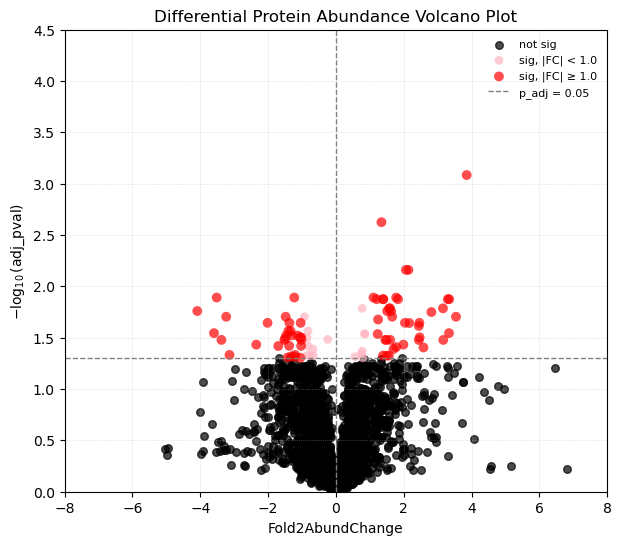

In [14]:

signif_cutoff=0.05
fc_threshold=1.0
alpha=0.7
fc_col = 'Fold2AbundChange'
pval_col = 'q_value'

# Prepare axes values
x = renorm_protein_sample_abundance[fc_col].astype(float)
y = -np.log10(renorm_protein_sample_abundance[pval_col].astype(float))

sig = renorm_protein_sample_abundance[pval_col] < signif_cutoff
large_fc = x.abs() >= fc_threshold
small_fc = (~large_fc) & sig

# Base scatter: non-significant
fig, ax = plt.subplots(figsize=(7,6))
ax.scatter(x[~sig], y[~sig], c="black", s=30, alpha=alpha, label="not sig")

# significant but small FC
ax.scatter(x[small_fc], y[small_fc], c="lightpink", edgecolor="none", s=40, alpha=alpha, label=f"sig, |FC| < {fc_threshold}")

# significant large FC
ax.scatter(x[sig & large_fc], y[sig & large_fc], c="red", edgecolor="none", s=50, alpha=alpha, label=f"sig, |FC| ≥ {fc_threshold}")

# Threshold lines
ax.axhline(-np.log10(signif_cutoff), linestyle="--", color="gray", linewidth=1, label=f"p_adj = {signif_cutoff}")
ax.axvline(0, linestyle="--", color="gray", linewidth=1)

ax.set_xlabel("Fold2AbundChange")
ax.set_ylabel(r"$-\log_{10}(\mathrm{adj\_pval})$")
ax.set_title("Differential Protein Abundance Volcano Plot")
ax.legend(frameon=False, fontsize=8)
ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)
ax.set_xlim([-8, 8])
ax.set_ylim([0,4.5])
plt.show()


[1]: https://github.com/lazear/sage?utm_source=chatgpt.com "lazear/sage: Proteomics search & quantification so fast that ... - GitHub"
[2]: https://lazear.github.io/sage/?utm_source=chatgpt.com "Proteomics searching so fast it seems like Magic"
[3]: https://www.researchgate.net/publication/374639418_Sage_An_Open-Source_Tool_for_Fast_Proteomics_Searching_and_Quantification_at_Scale?utm_source=chatgpt.com "Sage: An Open-Source Tool for Fast Proteomics Searching and ..."
[4]: https://pubmed.ncbi.nlm.nih.gov/37819886/?utm_source=chatgpt.com "Sage: An Open-Source Tool for Fast Proteomics ... - PubMed"
[5]: https://www.sciencedirect.com/science/article/pii/S1535947624000884?utm_source=chatgpt.com "Rescoring Peptide Spectrum Matches: Boosting Proteomics ..."
[6]: https://pmc.ncbi.nlm.nih.gov/articles/PMC4125737/?utm_source=chatgpt.com "Conserved Peptide Fragmentation as a Benchmarking Tool for Mass ..."